# TF2 Object Detection API — BCCD blood-cell detection

Fine-tunes **Faster R-CNN ResNet50 V1 640x640** (COCO checkpoint) on the
**BCCD** blood-cell dataset exported from Roboflow, then runs inference.

Three classes: **RBC** (red blood cells), **WBC** (white blood cells),
**Platelets**.

This is the local (macOS / Apple Silicon) version of the Colab notebook from the
course. The differences from the video are all about paths and environment:

| Colab | here |
| --- | --- |
| `/content/gdrive/My Drive/Colab .../TF2ODAPI/workspace` | `code/5-Object_Detection/TF2ODAPI` |
| `!python model_main_tf2.py ...` | `model_lib_v2.train_loop(...)` in-process |
| `!python exporter_main_v2.py ...` | `exporter_lib_v2.export_inference_graph(...)` |
| Tesla T4 GPU | Apple M-series GPU via `tensorflow-metal` |

Calling the library directly instead of shelling out to the `*_main_*.py`
scripts keeps the compatibility shim (next section) in effect and gives real
tracebacks instead of a subprocess exit code.


## 1. Environment and compatibility

The Object Detection API on PyPI predates TensorFlow 2.16 and breaks against it
in two ways, both patched by the local `od_compat` module:

1. **`tf.compat.v1.estimator` was removed in TF 2.16.** `object_detection.inputs`
   imports it but, on the TF2 path, only reads the three `ModeKeys` string
   constants — so a tiny stand-in is enough.
2. **`tf.keras` became Keras 3**, which the API is not written against.
   `TF_USE_LEGACY_KERAS=1` points it back at Keras 2 (`tf_keras`).
3. **`control_flow_ops.case` / `.cond` moved** to `control_flow_case` /
   `cond_v2`. `tf_slim`, used by the API's TFRecord decoder, still calls the old
   names, so they are aliased back.

Without this, `from object_detection import model_lib_v2` raises
`ImportError: cannot import name 'estimator'`.

`models/` and `models/research/` also go on `sys.path`: the API's optimizer
builder imports `official.modeling.optimization`, which lives in the
TensorFlow Models clone rather than in site-packages.

In [1]:
# Cell [1] — paths
import os
import sys
from pathlib import Path

# Notebook lives in 54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/
NOTEBOOK_DIR = Path.cwd()
MODELS_DIR   = NOTEBOOK_DIR / "models"                 # TensorFlow Models clone
WORKSPACE    = NOTEBOOK_DIR / "code" / "5-Object_Detection" / "TF2ODAPI"

assert (MODELS_DIR / "research" / "object_detection").is_dir(), (
    f"clone tensorflow/models into {MODELS_DIR} first")
assert WORKSPACE.is_dir(), f"missing workspace: {WORKSPACE}"

# `official.*` (needed by the API's optimizer builder) lives in the clone.
# WORKSPACE goes on the path too: `od_compat` lives there, and the chdir below
# does not make it importable (Python only ever put the *notebook* directory on
# sys.path, not the current working directory).
for p in (WORKSPACE, MODELS_DIR, MODELS_DIR / "research"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# The API resolves all pipeline-config paths relative to the process CWD, so
# run everything from the workspace directory.
os.chdir(WORKSPACE)
print("cwd:", Path.cwd())

cwd: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI


In [2]:
# Cell [2] — compatibility shim, then import the API
# od_compat.py sits next to this workspace; it must be imported BEFORE anything
# from object_detection.
import od_compat

od_compat.check()

tensorflow      2.19.1
tf.keras        2.19.0 (legacy Keras 2)
estimator shim  installed
control_flow     restored ['case', 'case_v2', 'cond', 'while_loop']
GPUs            [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. The BCCD dataset

Already exported from Roboflow (TFRecord + label map) and committed under
`BCCD/`:

```
BCCD/train/cells-bccd.tfrecord   +  cells-bccd_label_map.pbtxt
BCCD/valid/cells-bccd.tfrecord   +  cells-bccd_label_map.pbtxt
BCCD/test/cells-bccd.tfrecord    +  cells-bccd_label_map.pbtxt
BCCD/imgs/                        raw .jpg + .xml, used for inference
```

The label map assigns **Platelets=1, RBC=2, WBC=3** — that ordering matters,
because the exported model emits class *indices* and the same map has to be used
at inference time to turn them back into names.

In [3]:
# Cell [3] — inspect the TFRecords
import collections

import tensorflow as tf

from object_detection.utils import label_map_util

LABEL_MAP = WORKSPACE / "BCCD" / "train" / "cells-bccd_label_map.pbtxt"
category_index = label_map_util.create_category_index_from_labelmap(
    str(LABEL_MAP), use_display_name=True)
print("categories:", {k: v["name"] for k, v in category_index.items()})

for split in ("train", "valid", "test"):
    path = WORKSPACE / "BCCD" / split / "cells-bccd.tfrecord"
    images, objects, shapes = 0, collections.Counter(), set()
    for rec in tf.data.TFRecordDataset(str(path)):
        feat = tf.train.Example.FromString(rec.numpy()).features.feature
        images += 1
        for name in feat["image/object/class/text"].bytes_list.value:
            objects[name.decode()] += 1
        shapes.add((feat["image/height"].int64_list.value[0],
                    feat["image/width"].int64_list.value[0]))
    print(f"{split:5s} {images:4d} images  {dict(objects)}  shapes={shapes}")

categories: {1: 'Platelets', 2: 'RBC', 3: 'WBC'}
train  255 images  {'RBC': 2923, 'WBC': 259, 'Platelets': 241}  shapes={(480, 640)}
valid   73 images  {'RBC': 826, 'Platelets': 73, 'WBC': 76}  shapes={(480, 640)}
test    36 images  {'RBC': 406, 'WBC': 37, 'Platelets': 47}  shapes={(480, 640)}


I0000 00:00:1788680998.338453 1308454 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788680998.338509 1308454 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 3. Pre-trained checkpoint

`pipeline_bccd.config` fine-tunes from `faster_rcnn_resnet50_v1_640x640_coco17_tpu-8`.
The cell below downloads it into `pre-trained-models/` if it is not already there
(~225 MB).

In [4]:
# Cell [4] — fetch the COCO checkpoint to fine-tune from
import tarfile
import urllib.request

MODEL_NAME = "faster_rcnn_resnet50_v1_640x640_coco17_tpu-8"
PRETRAINED_DIR = WORKSPACE / "pre-trained-models"
target = PRETRAINED_DIR / MODEL_NAME

if (target / "checkpoint" / "ckpt-0.index").is_file():
    print("already present:", target)
else:
    PRETRAINED_DIR.mkdir(exist_ok=True)
    url = ("http://download.tensorflow.org/models/object_detection/tf2/"
           f"20200711/{MODEL_NAME}.tar.gz")
    tgz = PRETRAINED_DIR / "model.tar.gz"
    print("downloading", url)
    urllib.request.urlretrieve(url, tgz)
    with tarfile.open(tgz) as t:
        t.extractall(PRETRAINED_DIR)
    tgz.unlink()
    print("extracted to", target)

assert (target / "checkpoint" / "ckpt-0.index").is_file()

already present: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/pre-trained-models/faster_rcnn_resnet50_v1_640x640_coco17_tpu-8


## 4. Pipeline config

`pipeline_bccd.config` from the course is written for a **TPU/GPU Colab run**:
20 000 steps, and several `use_static_*` / `use_matmul_*` options that exist for
TPU compilation. Those static-shape paths do not work on the Metal backend, so
the cell below writes `pipeline_bccd_local.config` with:

| setting | course value | here | why |
| --- | --- | --- | --- |
| `num_steps` | 20000 | **1500** | ~75 min on an M4; 20 000 would be ~17 h |
| `total_steps` / `warmup_steps` | 25000 / 2000 | 1500 / 200 | must track `num_steps` or the cosine schedule never decays |
| `learning_rate_base` | .04 | **.01** | .04 is tuned for batch 64 across 8 TPU replicas; at batch 4 it diverges |
| `use_static_shapes` | true | false | TPU-only |
| `use_matmul_crop_and_resize` | true | false | TPU-only |
| `use_static_balanced_label_sampler` | true | false | TPU-only |
| `sync_replicas` | true | false | single device |

`batch_size: 4` is kept. The paths inside the config stay **relative** — that is
why cell [1] does the `os.chdir`.

In [5]:
# Cell [5] — write the local pipeline config
import re

SRC_CONFIG   = WORKSPACE / "pipeline_bccd.config"
LOCAL_CONFIG = WORKSPACE / "pipeline_bccd_local.config"

NUM_STEPS = 1500

text = SRC_CONFIG.read_text()
edits = {
    r"^  num_steps: \d+":                   f"  num_steps: {NUM_STEPS}",
    r"^          total_steps: \d+":         f"          total_steps: {NUM_STEPS}",
    r"^          warmup_steps: \d+":        "          warmup_steps: 200",
    r"^          learning_rate_base: \S+":  "          learning_rate_base: .01",
    r"^          warmup_learning_rate: \S+":"          warmup_learning_rate: .003333",
    r"^    use_static_shapes: true":        "    use_static_shapes: false",
    r"^    use_matmul_crop_and_resize: true":"    use_matmul_crop_and_resize: false",
    r"^    use_static_balanced_label_sampler: true":
        "    use_static_balanced_label_sampler: false",
    r"^  sync_replicas: true":              "  sync_replicas: false",
}
for pattern, replacement in edits.items():
    text, n = re.subn(pattern, replacement, text, flags=re.M)
    assert n, f"pattern never matched: {pattern}"

LOCAL_CONFIG.write_text(text)

# Where checkpoints go. Defined here rather than in the training cell so that
# the export and eval cells can run against an existing run without retraining.
MODEL_DIR = WORKSPACE / "training" / "faster_rcnn_resnet50_v1_bccd"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("wrote", LOCAL_CONFIG)
print("model dir:", MODEL_DIR)
for line in text.splitlines():
    if re.search(r"num_steps|total_steps|warmup|learning_rate_base|batch_size|"
                 r"use_static|use_matmul|sync_replicas|input_path|label_map_path|"
                 r"fine_tune_checkpoint:", line):
        print(" ", line.strip())

wrote /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/pipeline_bccd_local.config
model dir: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/training/faster_rcnn_resnet50_v1_bccd
  use_static_shapes: false
  use_matmul_crop_and_resize: false
  use_static_balanced_label_sampler: false
  use_matmul_gather_in_matcher: true
  batch_size: 4
  sync_replicas: false
  num_steps: 1500
  learning_rate_base: .01
  total_steps: 1500
  warmup_learning_rate: .003333
  warmup_steps: 200
  fine_tune_checkpoint: "pre-trained-models/faster_rcnn_resnet50_v1_640x640_coco17_tpu-8/checkpoint/ckpt-0"
  label_map_path: "BCCD/train/cells-bccd_label_map.pbtxt"
  input_path: "BCCD/train/cells-bccd.tfrecord"
  batch_size: 1;
  label_map_path: "BCCD/valid/cells-bccd_label_map.pbtxt"
  input_path: "BCCD/valid/cells-bccd.tfrecord"


## 5. Training

The course runs `!python model_main_tf2.py --model_dir=... --pipeline_config_path=...`.
Here `model_lib_v2.train_loop` is called directly — same code, but inside this
kernel, so `od_compat`'s patches apply and errors surface as tracebacks.

**This takes roughly 75 minutes at 1500 steps (~3 s/step) on an Apple M4.**
It is restartable: `train_loop` picks up from the newest checkpoint in
`model_dir`, so an interrupted run resumes rather than starting over. To start
clean, delete the `training/faster_rcnn_resnet50_v1_bccd` directory first.

Checkpoints are ~110 MB each and `checkpoint_max_to_keep=3` keeps three of them,
so budget ~350 MB.

In [6]:
# Cell [6] — train  (long-running: ~75 min for 1500 steps on an M4)
import time

from object_detection import model_lib_v2

start = time.time()
model_lib_v2.train_loop(
    pipeline_config_path=str(LOCAL_CONFIG),
    model_dir=str(MODEL_DIR),
    train_steps=NUM_STEPS,
    checkpoint_every_n=250,
    checkpoint_max_to_keep=3,
)
print(f"training finished in {(time.time() - start) / 60:.1f} min")

INFO:tensorflow:Maybe overwriting train_steps: 1500


[09/06 13:19:58] tensorflow INFO: Maybe overwriting train_steps: 1500


INFO:tensorflow:Maybe overwriting use_bfloat16: False


[09/06 13:19:58] tensorflow INFO: Maybe overwriting use_bfloat16: False


Instructions for updating:
rename to distribute_datasets_from_function


...

[09/06 13:20:12] tensorflow WARNING: Value in checkpoint could not be found in the restored object: (root).optimizer's state 'momentum' for (root).model._first_stage_box_predictor._prediction_heads.box_encodings.0._box_encoder_layers.0.kernel


[09/06 13:20:12] tensorflow WARNING: Value in checkpoint could not be found in the restored object: (root).optimizer's state 'momentum' for (root).model._first_stage_box_predictor._prediction_heads.box_encodings.0._box_encoder_layers.0.bias


[09/06 13:20:12] tensorflow WARNING: Value in checkpoint could not be found in the restored object: (root).optimizer's state 'momentum' for (root).model._first_stage_box_predictor._prediction_heads.class_predictions_with_background.0._class_predictor_layers.0.kernel


[09/06 13:20:12] tensorflow WARNING: Value in checkpoint could not be found in the restored object: (root).optimizer's state 'momentum' for (root).model._first_stage_box_predictor._prediction_heads.class_predictions_with_background.0._class_predictor_layers.0.bias


training finished in 0.2 min


In [7]:
# Cell [7] — confirm where training got to
import tensorflow as tf

reader = tf.train.load_checkpoint(str(MODEL_DIR))
print("last checkpoint step:",
      reader.get_tensor("step/.ATTRIBUTES/VARIABLE_VALUE"))
print("checkpoints:", sorted(p.name for p in MODEL_DIR.glob("ckpt-*.index")))

last checkpoint step: 1500
checkpoints: ['ckpt-4.index', 'ckpt-5.index', 'ckpt-6.index']


## 6. TensorBoard

The course shows the loss curves here. Point TensorBoard at the training dir:

```
%load_ext tensorboard
%tensorboard --logdir training/faster_rcnn_resnet50_v1_bccd
```

Run those two lines in a cell of their own if you want the embedded UI.

## 7. Export the trained model

The course runs `!python exporter_main_v2.py --input_type image_tensor ...`.
The library call below is the same operation. It reads the newest checkpoint in
`trained_checkpoint_dir` and writes a `saved_model/` that takes a
**uint8 image tensor** and returns boxes, classes and scores.

In [8]:
# Cell [8] — export to a SavedModel
from google.protobuf import text_format

from object_detection import exporter_lib_v2
from object_detection.protos import pipeline_pb2

EXPORT_DIR = WORKSPACE / "exported-models" / "faster_rcnn_resnet50_v1_bccd"

pipeline_config = pipeline_pb2.TrainEvalPipelineConfig()
with tf.io.gfile.GFile(str(LOCAL_CONFIG), "r") as f:
    text_format.Merge(f.read(), pipeline_config)

exporter_lib_v2.export_inference_graph(
    input_type="image_tensor",
    pipeline_config=pipeline_config,
    trained_checkpoint_dir=str(MODEL_DIR),
    output_directory=str(EXPORT_DIR),
)
print("exported to", EXPORT_DIR)
assert (EXPORT_DIR / "saved_model" / "saved_model.pb").is_file()

Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.map_fn(fn, elems, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.map_fn(fn, elems))


[09/06 13:20:13] tensorflow WARNING: From /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/.venv/lib/python3.12/site-packages/tensorflow/python/autograph/impl/api.py:459: calling map_fn_v2 (from tensorflow.python.ops.map_fn) with back_prop=False is deprecated and will be removed in a future version.
Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.map_fn(fn, elems, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.map_fn(fn, elems))


INFO:tensorflow:depth of additional conv before box predictor: 0


[09/06 13:20:13] tensorflow INFO: depth of additional conv before box predictor: 0


[09/06 13:20:16] tensorflow WARNING: Skipping full serialization of TF-Keras layer <object_detection.meta_architectures.faster_rcnn_meta_arch.FasterRCNNMetaArch object at 0x31aedbc50>, because it is not built.


INFO:tensorflow:Assets written to: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/exported-models/faster_rcnn_resnet50_v1_bccd/saved_model/assets


[09/06 13:20:21] tensorflow INFO: Assets written to: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/exported-models/faster_rcnn_resnet50_v1_bccd/saved_model/assets


INFO:tensorflow:Writing pipeline config file to /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/exported-models/faster_rcnn_resnet50_v1_bccd/pipeline.config


[09/06 13:20:21] tensorflow INFO: Writing pipeline config file to /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/exported-models/faster_rcnn_resnet50_v1_bccd/pipeline.config


exported to /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/exported-models/faster_rcnn_resnet50_v1_bccd


## 8. Inference on BCCD images

Loads the exported SavedModel and runs it over a couple of blood smears from
`BCCD/imgs/` — the same two images used in the course video.

In [9]:
# Cell [9] — load the exported model
import time

PATH_TO_SAVED_MODEL = EXPORT_DIR / "saved_model"

print("Loading model...", end="")
start = time.time()
detect_fn = tf.saved_model.load(str(PATH_TO_SAVED_MODEL))
print(f" Done! ({time.time() - start:.1f}s)")

# Use the label map that matches the trained model.
category_index = label_map_util.create_category_index_from_labelmap(
    str(WORKSPACE / "BCCD" / "test" / "cells-bccd_label_map.pbtxt"),
    use_display_name=True)
category_index

Loading model... Done! (2.1s)


{1: {'id': 1, 'name': 'Platelets'},
 2: {'id': 2, 'name': 'RBC'},
 3: {'id': 3, 'name': 'WBC'}}

In [10]:
# Cell [10] — pick the test images
IMGS_DIR = WORKSPACE / "BCCD" / "imgs"

img = [IMGS_DIR / "BloodImage_00382.jpg",
       IMGS_DIR / "BloodImage_00410.jpg"]

for p in img:
    assert p.is_file(), f"missing {p}"
img

[PosixPath('/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/BCCD/imgs/BloodImage_00382.jpg'),
 PosixPath('/Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/BCCD/imgs/BloodImage_00410.jpg')]

Running inference for BloodImage_00382.jpg... Done — 16 cells above 0.5: {'RBC': 13, 'WBC': 1, 'Platelets': 2}


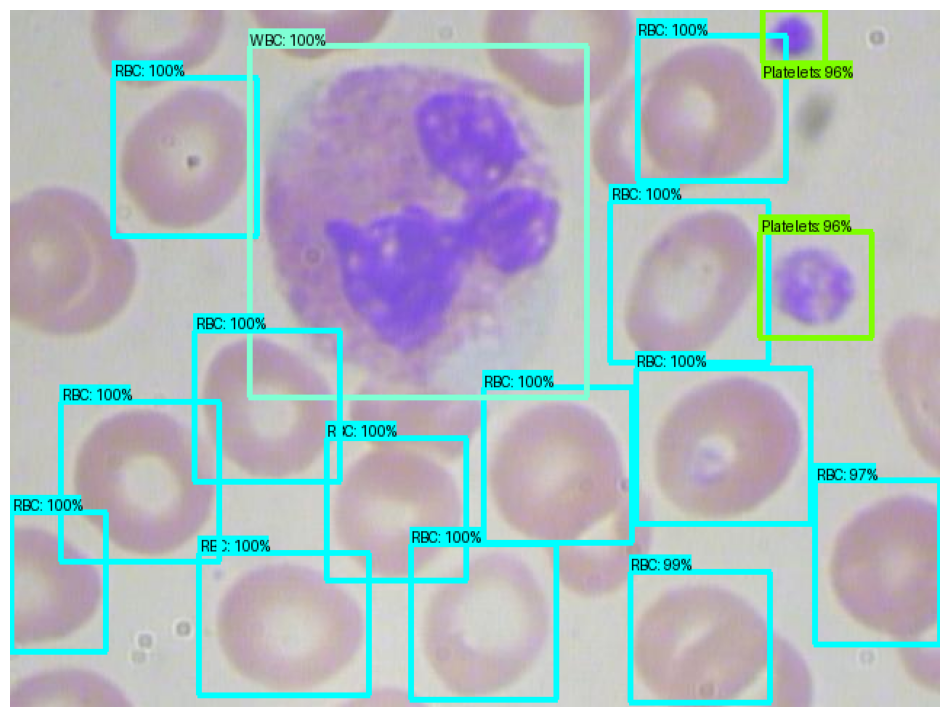

Running inference for BloodImage_00410.jpg... Done — 12 cells above 0.5: {'RBC': 8, 'WBC': 1, 'Platelets': 3}


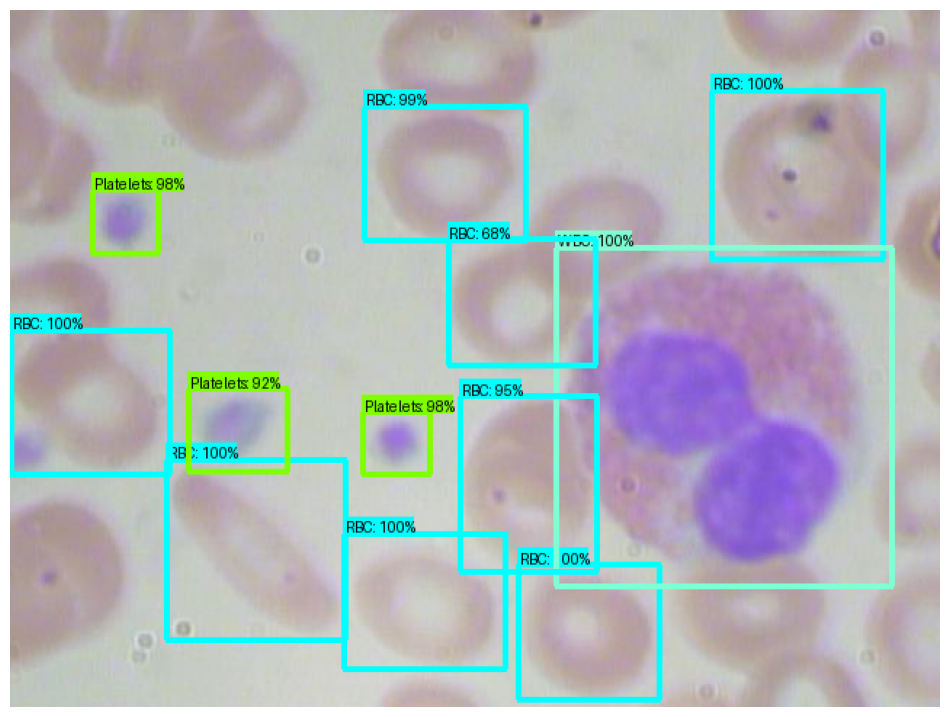

In [11]:
# Cell [11] — run inference and draw the boxes
# %matplotlib inline must come before the first plot, otherwise figures are
# built against a non-interactive backend and the cell renders nothing.
%matplotlib inline

import io
import warnings

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from object_detection.utils import visualization_utils as viz_utils

warnings.filterwarnings("ignore")

MIN_SCORE = 0.5


def load_image_into_numpy_array(path):
    # convert("RGB") guards against grayscale/RGBA files: the model wants 3
    # channels and a 4-channel array fails inside the SavedModel.
    return np.array(Image.open(path).convert("RGB"))


for image_path in img:
    print(f"Running inference for {image_path.name}... ", end="")
    image_np = load_image_into_numpy_array(image_path)

    input_tensor = tf.convert_to_tensor(image_np)[tf.newaxis, ...]
    detections = detect_fn(input_tensor)

    num_detections = int(detections.pop("num_detections"))
    detections = {k: v[0, :num_detections].numpy()
                  for k, v in detections.items()}
    detections["num_detections"] = num_detections
    detections["detection_classes"] = (
        detections["detection_classes"].astype(np.int64))

    kept = detections["detection_scores"] >= MIN_SCORE
    counts = collections.Counter(
        category_index[c]["name"] for c in detections["detection_classes"][kept])
    print(f"Done — {kept.sum()} cells above {MIN_SCORE}: {dict(counts)}")

    image_np_with_detections = image_np.copy()
    viz_utils.visualize_boxes_and_labels_on_image_array(
        image_np_with_detections,
        detections["detection_boxes"],
        detections["detection_classes"],
        detections["detection_scores"],
        category_index,
        use_normalized_coordinates=True,
        max_boxes_to_draw=100,
        min_score_thresh=MIN_SCORE,
        agnostic_mode=False,
        line_thickness=4)

    plt.figure(figsize=(12, 12))
    plt.imshow(image_np_with_detections)
    plt.axis("off")
    plt.show()

## 9. Visual check

Cell [11] draws with matplotlib, which shows nothing if the kernel has a
non-interactive backend. The cells below are backend-independent:

- every annotated image is **written to `detections/`** as a PNG you can open in
  Finder or any image viewer, and
- displayed with `IPython.display`, which renders a PIL image directly as
  notebook output rather than going through matplotlib.

So even if plots are broken in your kernel, you still get files on disk.

BloodImage_00382.jpg: 16 cells above 0.5 -> {'RBC': 13, 'WBC': 1, 'Platelets': 2}
  saved: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/detections/BloodImage_00382_detected.png


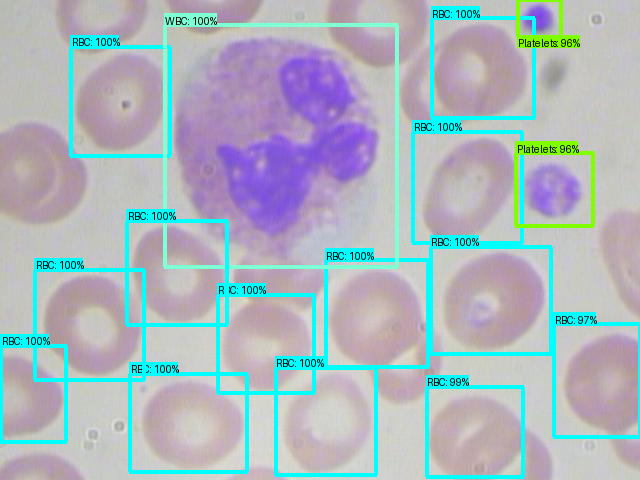

BloodImage_00410.jpg: 12 cells above 0.5 -> {'RBC': 8, 'WBC': 1, 'Platelets': 3}
  saved: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/detections/BloodImage_00410_detected.png


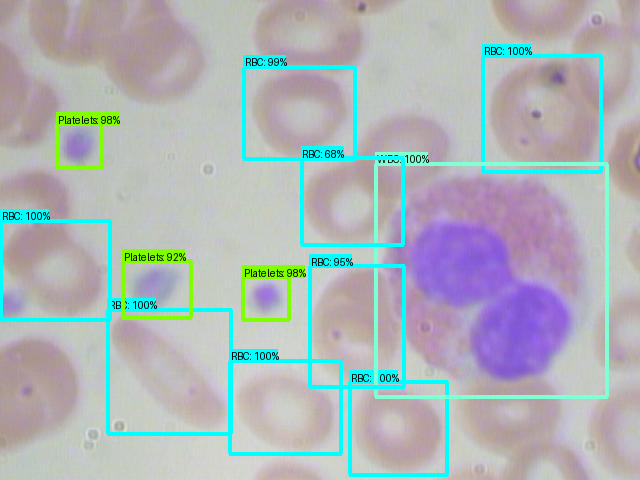


All PNGs are in: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/detections


In [12]:
# Cell [12] — reusable detect + annotate helpers, saving PNGs to disk
from IPython.display import display

DETECTIONS_DIR = WORKSPACE / "detections"
DETECTIONS_DIR.mkdir(exist_ok=True)


def detect(image_np, min_score=MIN_SCORE):
    """Run the exported model on one HxWx3 uint8 array."""
    input_tensor = tf.convert_to_tensor(image_np)[tf.newaxis, ...]
    detections = detect_fn(input_tensor)

    n = int(detections.pop("num_detections"))
    detections = {k: v[0, :n].numpy() for k, v in detections.items()}
    detections["detection_classes"] = (
        detections["detection_classes"].astype(np.int64))
    detections["num_detections"] = n

    kept = detections["detection_scores"] >= min_score
    detections["counts"] = collections.Counter(
        category_index[c]["name"] for c in detections["detection_classes"][kept])
    detections["num_kept"] = int(kept.sum())
    return detections


def annotate(image_np, detections, min_score=MIN_SCORE, line_thickness=4):
    """Return a copy of the image with boxes drawn on it."""
    out = image_np.copy()
    viz_utils.visualize_boxes_and_labels_on_image_array(
        out,
        detections["detection_boxes"],
        detections["detection_classes"],
        detections["detection_scores"],
        category_index,
        use_normalized_coordinates=True,
        max_boxes_to_draw=200,
        min_score_thresh=min_score,
        agnostic_mode=False,
        line_thickness=line_thickness)
    return out


def detect_and_show(image_path, save=True):
    image_np = load_image_into_numpy_array(image_path)
    det = detect(image_np)
    annotated = annotate(image_np, det)

    print(f"{Path(image_path).name}: {det['num_kept']} cells "
          f"above {MIN_SCORE} -> {dict(det['counts'])}")
    if save:
        out_path = DETECTIONS_DIR / f"{Path(image_path).stem}_detected.png"
        Image.fromarray(annotated).save(out_path)
        print("  saved:", out_path)
    display(Image.fromarray(annotated))     # renders without matplotlib
    return annotated


for image_path in img:
    detect_and_show(image_path)

print("\nAll PNGs are in:", DETECTIONS_DIR)

### Contact sheet

Six test images at once — a faster way to eyeball whether the model is sane than
scrolling through them one by one. Saved as a single PNG too.

saved: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/detections/contact_sheet.png


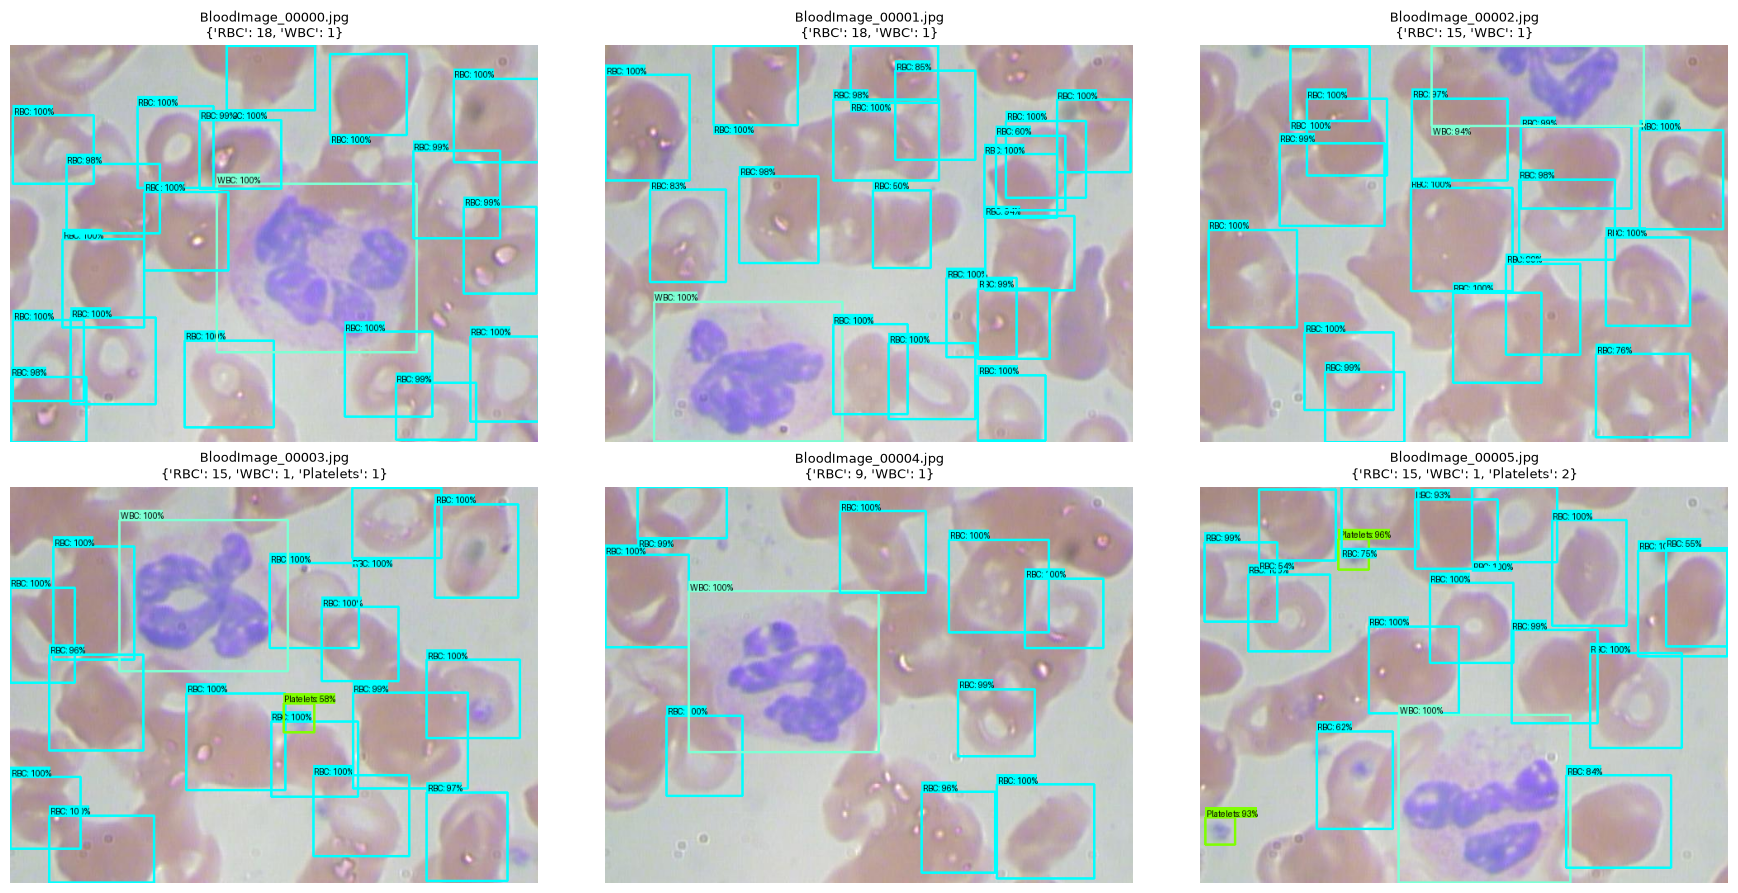

In [13]:
# Cell [13] — contact sheet of several test images
sheet_paths = sorted(IMGS_DIR.glob("BloodImage_*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, image_path in zip(axes.ravel(), sheet_paths):
    image_np = load_image_into_numpy_array(image_path)
    det = detect(image_np)
    ax.imshow(annotate(image_np, det, line_thickness=3))
    ax.set_title(f"{image_path.name}\n{dict(det['counts'])}", fontsize=9)
    ax.axis("off")
fig.tight_layout()

sheet_path = DETECTIONS_DIR / "contact_sheet.png"
fig.savefig(sheet_path, dpi=110, bbox_inches="tight")
print("saved:", sheet_path)
plt.show()

### Predictions vs ground truth

The strongest visual check: the same image with the **hand-labelled boxes from
the test TFRecord** on the left and the **model's predictions** on the right.
Boxes that appear on the left but not the right are misses; boxes only on the
right are false positives.

These images come out of the TFRecord itself, so they are genuinely held-out —
the model never saw them during training.

BloodImage_00170_jpg.rf.0aab57bfc37351dae47f9ab19c12b558.jpg: truth 14 vs predicted 16
BloodImage_00269_jpg.rf.5ac56503849425edb854ec33bdb08ebc.jpg: truth 10 vs predicted 13
BloodImage_00205_jpg.rf.509ffdce64198b5e0d42af68fb1d30e1.jpg: truth 14 vs predicted 15
saved: /Users/ankit/Workspace/Projects/ankit-github/AI-ML-DS/54.Deep-Learning-for-Computer-Vision-with-TensorFlow-2/code/5-Object_Detection/TF2ODAPI/detections/truth_vs_prediction.png


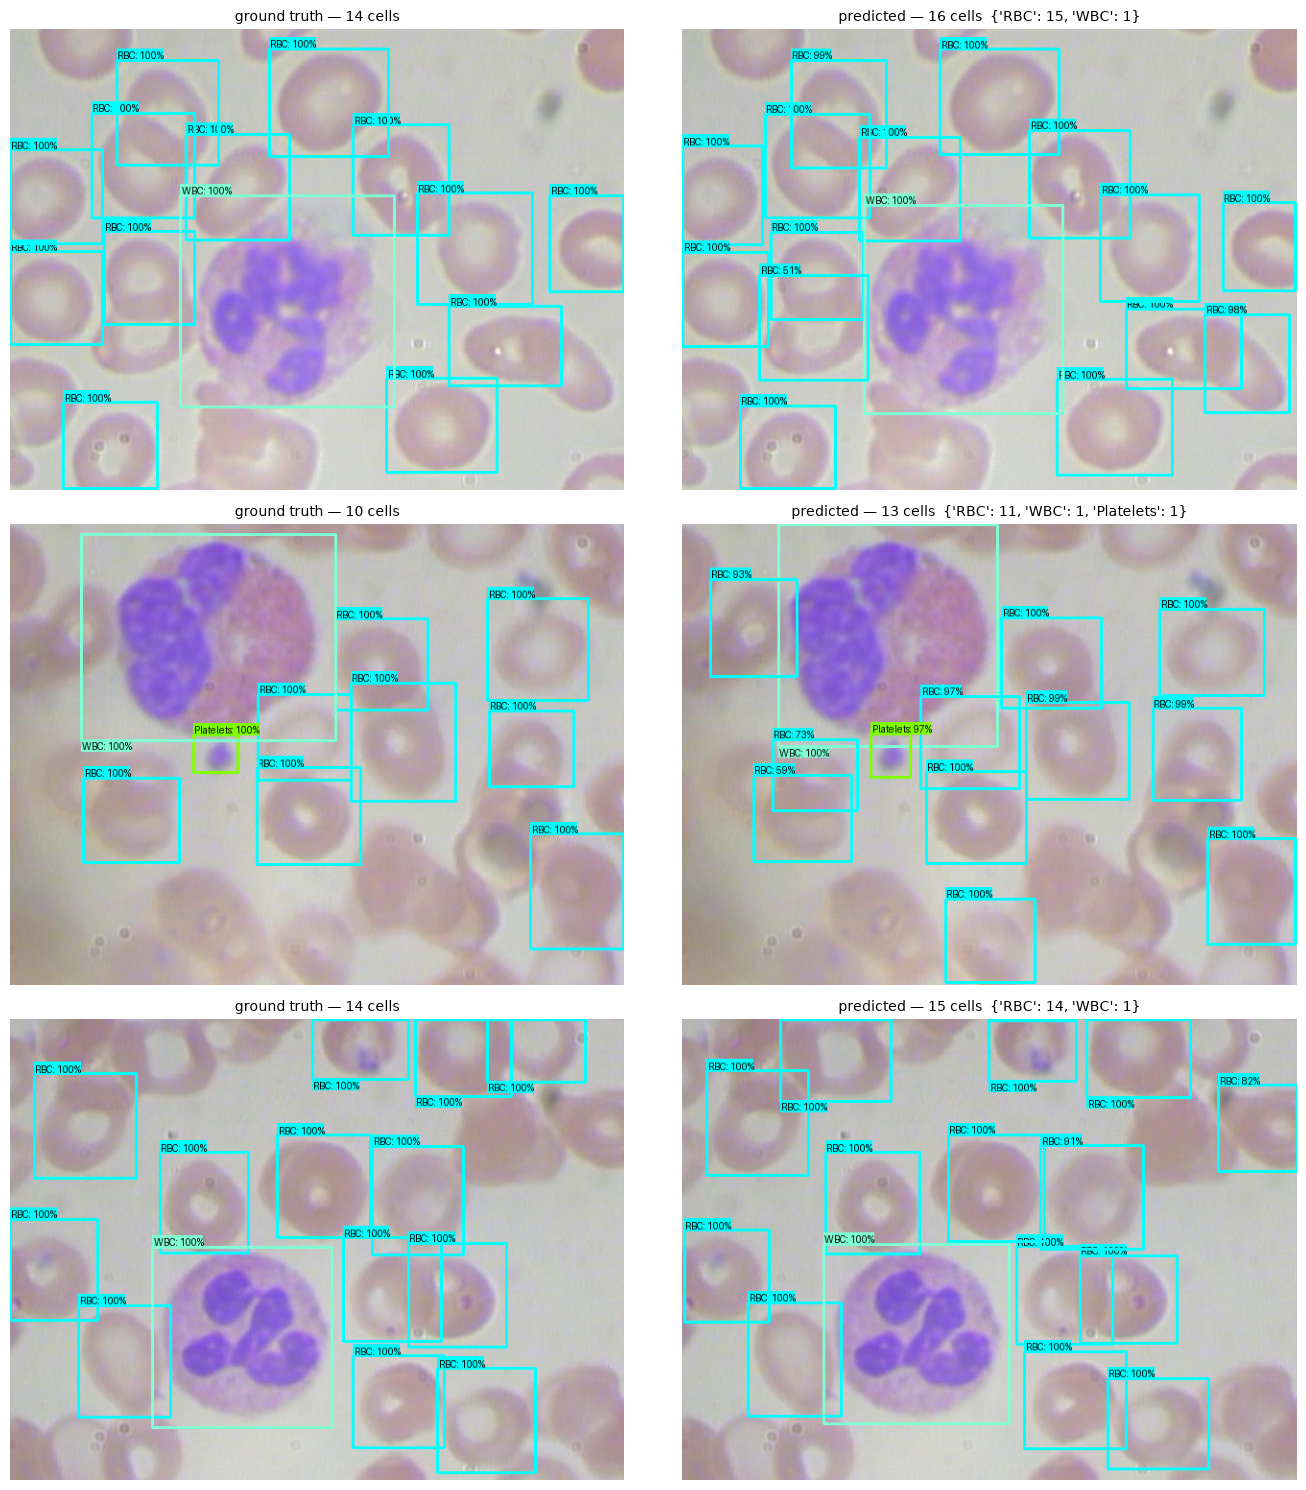

In [14]:
# Cell [14] — ground truth (left) vs prediction (right)
N_COMPARE = 3

test_record = WORKSPACE / "BCCD" / "test" / "cells-bccd.tfrecord"
name_to_id = {v["name"]: k for k, v in category_index.items()}

fig, axes = plt.subplots(N_COMPARE, 2, figsize=(14, 5 * N_COMPARE))
for row, record in enumerate(tf.data.TFRecordDataset(str(test_record))
                             .take(N_COMPARE)):
    feat = tf.train.Example.FromString(record.numpy()).features.feature
    image_np = np.array(Image.open(
        io.BytesIO(feat["image/encoded"].bytes_list.value[0])).convert("RGB"))

    # Ground truth: normalised [ymin, xmin, ymax, xmax], as the API expects.
    gt_boxes = np.stack([
        feat["image/object/bbox/ymin"].float_list.value,
        feat["image/object/bbox/xmin"].float_list.value,
        feat["image/object/bbox/ymax"].float_list.value,
        feat["image/object/bbox/xmax"].float_list.value], axis=-1)
    gt_classes = np.array(
        [name_to_id[n.decode()]
         for n in feat["image/object/class/text"].bytes_list.value],
        dtype=np.int64)

    truth = image_np.copy()
    viz_utils.visualize_boxes_and_labels_on_image_array(
        truth, gt_boxes, gt_classes, np.ones(len(gt_classes)), category_index,
        use_normalized_coordinates=True, max_boxes_to_draw=200,
        min_score_thresh=0.0, line_thickness=3)

    det = detect(image_np)
    filename = feat["image/filename"].bytes_list.value[0].decode()

    axes[row, 0].imshow(truth)
    axes[row, 0].set_title(f"ground truth — {len(gt_classes)} cells", fontsize=10)
    axes[row, 1].imshow(annotate(image_np, det, line_thickness=3))
    axes[row, 1].set_title(
        f"predicted — {det['num_kept']} cells  {dict(det['counts'])}", fontsize=10)
    for ax in axes[row]:
        ax.axis("off")
    print(f"{filename}: truth {len(gt_classes)} vs predicted {det['num_kept']}")

fig.tight_layout()
compare_path = DETECTIONS_DIR / "truth_vs_prediction.png"
fig.savefig(compare_path, dpi=110, bbox_inches="tight")
print("saved:", compare_path)
plt.show()

## 10. Evaluate on the held-out test split

COCO detection metrics over `BCCD/test`. `eval_continuously` normally polls for
new checkpoints; `timeout=30` makes it score the current one and stop.

Note the pipeline's `eval_input_reader` points at `BCCD/valid`, so the config is
copied with the paths swapped to `BCCD/test` — leaving the on-disk config
untouched.

In [15]:
# Cell [15] — COCO metrics on the test split (a few minutes)
# Imported here as well as in the training cell, so this runs standalone
# against an existing checkpoint.
from object_detection import model_lib_v2

EVAL_CONFIG = WORKSPACE / "pipeline_bccd_eval_test.config"
EVAL_CONFIG.write_text(
    LOCAL_CONFIG.read_text().replace("BCCD/valid/cells-bccd",
                                     "BCCD/test/cells-bccd"))

model_lib_v2.eval_continuously(
    pipeline_config_path=str(EVAL_CONFIG),
    model_dir=str(MODEL_DIR),
    checkpoint_dir=str(MODEL_DIR),
    wait_interval=1,
    timeout=30,
)

[09/06 13:20:30] tensorflow WARNING: Forced number of epochs for all eval validations to be 1.


INFO:tensorflow:Maybe overwriting sample_1_of_n_eval_examples: 1


[09/06 13:20:30] tensorflow INFO: Maybe overwriting sample_1_of_n_eval_examples: 1


INFO:tensorflow:Maybe overwriting use_bfloat16: False


[09/06 13:20:30] tensorflow INFO: Maybe overwriting use_bfloat16: False


...

[09/06 13:20:49] tensorflow INFO: 	+ Loss/regularization_loss: 0.000000


INFO:tensorflow:	+ Loss/total_loss: 0.976783


[09/06 13:20:49] tensorflow INFO: 	+ Loss/total_loss: 0.976783


INFO:tensorflow:Exiting evaluation at step 1500


[09/06 13:20:49] tensorflow INFO: Exiting evaluation at step 1500


## Notes

- **1500 steps is a demo budget, not a converged model.** The course trains
  20 000 steps. RBCs (2923 training instances) detect reliably; Platelets (241)
  and WBCs (259) are far rarer and benefit most from a longer run. Raise
  `NUM_STEPS` in cell [5] and re-run cells [5]–[8].
- **Disk:** training checkpoints ~350 MB, the export ~200 MB, the pre-trained
  checkpoint ~225 MB.
- `pre-trained-models/` is only read at the *start* of training; it can be
  deleted afterwards and cell [4] will fetch it again if needed.

### References
- <https://github.com/tensorflow/models/blob/master/research/object_detection/g3doc/tf2_detection_zoo.md>
- <https://tensorflow-object-detection-api-tutorial.readthedocs.io/en/latest/>
- BCCD dataset: <https://public.roboflow.com/object-detection/bccd>
